In [16]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
import seaborn as sns
import matplotlib.pyplot as plt
adata = sc.read_h5ad("../data/processed/Filbin_step3.h5ad")

In [ ]:
print(f"shape: {adata.shape}        (anchor: 2458 x 8494)")
print(f"layers: {list(adata.layers.keys())}   (anchor: tpm, centered)")

print("\nPer-patient counts:")
print(adata.obs["patient"].value_counts())
print("(anchors: MUV5 708, BCH836 527, BCH869 492, BCH1126 299, MUV10 286, MUV1 146)")

X = np.asarray(adata.X)
print(f"\n.X mean           = {X.mean():.4f}   (anchor: 1.428)")
print(f".X zero fraction  = {(X == 0).mean():.4f}   (anchor: 0.544)")
print(f".X range          = [{X.min():.2f}, {X.max():.2f}]   (anchor: [0, 15.15])")

Er = np.asarray(adata.layers["centered"])
print(f"\ncentered mean    = {Er.mean():.2e}   (anchor: ~1e-8)")
print(f"centered std     = {Er.std():.4f}   (anchor: ~1.64)")
print(f"centered range   = [{Er.min():.2f}, {Er.max():.2f}]   (anchor: ~[-9.3, +15.1])")

print(f"\nEa min           = {adata.var['Ea'].min():.4f}   (anchor: >= 4.0)")

shape: (2458, 8494)        (anchor: 2458 x 8494)
layers: ['centered', 'tpm']   (anchor: tpm, centered)

Per-patient counts:
MUV5       708
BCH836     527
BCH869     492
BCH1126    299
MUV10      286
MUV1       146
Name: patient, dtype: int64
(anchors: MUV5 708, BCH836 527, BCH869 492, BCH1126 299, MUV10 286, MUV1 146)

.X mean           = 1.4282   (anchor: 1.428)
.X zero fraction  = 0.5439   (anchor: 0.544)
.X range          = [0.00, 15.15]   (anchor: [0, 15.15])

centered mean    = 1.19e-08   (anchor: ~1e-8)
centered std     = 1.6411   (anchor: ~1.64)
centered range   = [-9.32, 15.10]   (anchor: ~[-9.3, +15.1])

Ea min           = 4.0002   (anchor: >= 4.0)


In [4]:
# Cell-cell Pearson on per-tumor centered expression


Er = np.asarray(adata.layers["centered"])   # (2458, 8494), float32
print(f"input: shape {Er.shape}, dtype {Er.dtype}")

# np.corrcoef: rows are variables -> rows of Er are cells -> output is cell-cell
C = np.corrcoef(Er).astype(np.float32)
print(f"correlation matrix: shape {C.shape}, dtype {C.dtype}, size {C.nbytes / 1e6:.1f} MB")

# Mechanical sanity
print(f"\nsymmetry  max |C - C.T| : {np.max(np.abs(C - C.T)):.2e}   (expect ~0)")
print(f"diagonal  min / max     : {np.diag(C).min():.6f} / {np.diag(C).max():.6f}   (expect 1.0)")
iu = np.triu_indices_from(C, k=1)
off = C[iu]
print(f"off-diag  range         : [{off.min():.3f}, {off.max():.3f}]")
print(f"off-diag  median / mean : {np.median(off):+.4f} / {off.mean():+.4f}")

input: shape (2458, 8494), dtype float32
correlation matrix: shape (2458, 2458), dtype float32, size 24.2 MB

symmetry  max |C - C.T| : 0.00e+00   (expect ~0)
diagonal  min / max     : 1.000000 / 1.000000   (expect 1.0)
off-diag  range         : [-0.157, 0.970]
off-diag  median / mean : -0.0005 / -0.0003


In [5]:
# Within-tumor vs cross-tumor correlation distribution
patients = adata.obs["patient"].to_numpy()
same_tumor = patients[:, None] == patients[None, :]

corr_vals = C[iu]
same_mask = same_tumor[iu]
within = corr_vals[same_mask]
cross  = corr_vals[~same_mask]

print(f"\nWithin-tumor pairs ({len(within):>9,}):  "
      f"median {np.median(within):+.4f}  mean {within.mean():+.4f}  std {within.std():.4f}")
print(f"Cross-tumor pairs  ({len(cross):>9,}):  "
      f"median {np.median(cross):+.4f}  mean {cross.mean():+.4f}  std {cross.std():.4f}")
print(f"Mean(within) - Mean(cross) = {within.mean() - cross.mean():+.4f}")


Within-tumor pairs (  605,556):  median -0.0024  mean -0.0018  std 0.0482
Cross-tumor pairs  (2,414,097):  median -0.0002  mean +0.0001  std 0.0296
Mean(within) - Mean(cross) = -0.0019


In [6]:
print("obs columns:", list(adata.obs.columns))
print()
for col in ["sample", "source", "model", "cell_type"]:
    if col in adata.obs.columns:
        print(f"--- {col} ---")
        print(adata.obs[col].value_counts())
        print()

obs columns: ['sample', 'patient', 'source', 'model', 'is_paper_patient', 'in_paper_cohort', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'hk_score', 'hk_score_hounkpe']

--- sample ---
MUV5       708
BCH836     527
BCH869     492
BCH1126    299
MUV10      286
MUV1       146
Name: sample, dtype: int64

--- source ---
patient    2458
Name: source, dtype: int64

--- model ---
primary_tumor    2458
Name: model, dtype: int64



In [8]:
adata


AnnData object with n_obs × n_vars = 2458 × 8494
    obs: 'sample', 'patient', 'source', 'model', 'is_paper_patient', 'in_paper_cohort', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'hk_score', 'hk_score_hounkpe'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mt', 'ribo', 'hb', 'Ea'
    layers: 'centered', 'tpm'

In [9]:
adata.X[:5, :5]

array([[0.       , 0.       , 0.       , 0.       , 0.       ],
       [0.       , 0.       , 0.       , 0.       , 0.       ],
       [0.       , 0.       , 5.930288 , 0.       , 0.       ],
       [0.       , 5.5381036, 0.       , 0.       , 0.       ],
       [5.1638207, 2.713476 , 0.       , 0.       , 0.       ]],
      dtype=float32)

In [10]:
adata.obs.head()

,sample,patient,source,model,is_paper_patient,in_paper_cohort,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,total_counts_hb,pct_counts_hb,hk_score,hk_score_hounkpe
MUV1-P04-B12,MUV1,MUV1,patient,primary_tumor,True,True,4811,1000000.27,0.0,0.0,103137.99,10.313796,0.00,0.000000,1.100522,1.367351
MUV1-P04-C08,MUV1,MUV1,patient,primary_tumor,True,True,2617,1000000.27,0.0,0.0,204042.17,20.404211,0.00,0.000000,0.801043,1.049534
MUV1-P04-D09,MUV1,MUV1,patient,primary_tumor,True,True,4628,1000000.04,0.0,0.0,44548.76,4.454876,0.00,0.000000,0.982385,1.279895
MUV1-P04-D10,MUV1,MUV1,patient,primary_tumor,True,True,4882,1000000.11,0.0,0.0,97054.54,9.705453,0.00,0.000000,1.140262,1.525434
MUV1-P04-E03,MUV1,MUV1,patient,primary_tumor,True,True,5927,1000000.37,0.0,0.0,38951.45,3.895144,19.25,0.001925,1.394313,1.650908


In [11]:
adata.obs.columns

Index(['sample', 'patient', 'source', 'model', 'is_paper_patient',
       'in_paper_cohort', 'n_genes_by_counts', 'total_counts',
       'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'hk_score',
       'hk_score_hounkpe'],
      dtype='object')

In [12]:
adata.var.head()

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,mt,ribo,hb,Ea
Gene,,,,,,,,
A2M,966,171.771412,76.195170,697048.39,False,False,False,6.444528
AAAS,1701,69.805473,58.082799,283270.61,False,False,False,6.230818
AACS,1039,17.232048,74.396254,69927.65,False,False,False,4.145992
AADAT,919,20.766848,77.353376,84271.87,False,False,False,4.736881
AAGAB,1497,38.298682,63.109906,155416.05,False,False,False,5.028065


In [13]:
adata.var.columns

Index(['n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts',
       'total_counts', 'mt', 'ribo', 'hb', 'Ea'],
      dtype='object')

In [14]:
adata.layers.keys()

KeysView(Layers with keys: centered, tpm)

In [15]:
adata.uns.keys()

odict_keys([])

In [17]:
# Use centered expression, equivalent to Filbin's Er
X = adata.layers["centered"]

# Convert sparse to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

X = X.astype(np.float32)

print(X.shape)

(2458, 8494)


In [18]:
# Pearson correlation between cells
corr = np.corrcoef(X)

# Numerical cleanup
corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)

corr_df = pd.DataFrame(
    corr,
    index=adata.obs_names,
    columns=adata.obs_names
)

corr_df.shape

(2458, 2458)

In [19]:
# Convert correlation to distance
dist = 1 - corr

# Force diagonal to zero
np.fill_diagonal(dist, 0)

# Make sure distance is symmetric
dist = (dist + dist.T) / 2

# Convert square distance matrix to condensed form
dist_condensed = squareform(dist, checks=False)

# Complete-linkage hierarchical clustering
Z = linkage(dist_condensed, method="complete")

# Get ordered cell indices
order = leaves_list(Z)

# Reorder correlation matrix
corr_ordered = corr_df.iloc[order, order]

# Store ordering in adata
adata.obs["corr_order"] = np.nan
adata.obs.iloc[order, adata.obs.columns.get_loc("corr_order")] = np.arange(len(order))

corr_ordered.shape

/tmp/ipykernel_1273885/3282534717.py:24: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  adata.obs.iloc[order, adata.obs.columns.get_loc("corr_order")] = np.arange(len(order))


(2458, 2458)

In [20]:
sample_ordered = adata.obs.iloc[order]["sample"]

# Create sample color annotation
unique_samples = sample_ordered.unique()
palette = sns.color_palette("tab10", n_colors=len(unique_samples))
sample_lut = dict(zip(unique_samples, palette))
sample_colors = sample_ordered.map(sample_lut)

g = sns.clustermap(
    corr_ordered,
    row_cluster=False,
    col_cluster=False,
    row_colors=sample_colors,
    col_colors=sample_colors,
    cmap="vlag",
    center=0,
    vmin=-0.1,
    vmax=0.2,
    xticklabels=False,
    yticklabels=False,
    figsize=(12, 12)
)

plt.suptitle("Filbin-style cell-cell Pearson correlation heatmap", y=1.02)
plt.show()

NotImplementedError: isna is not defined for MultiIndex

In [21]:
print(type(corr_ordered.index))
print(type(corr_ordered.columns))
print(type(adata.obs.index))
print(type(adata.obs["sample"].index))

<class 'pandas.core.indexes.base.Index'>
<class 'pandas.core.indexes.base.Index'>
<class 'pandas.core.indexes.base.Index'>
<class 'pandas.core.indexes.base.Index'>


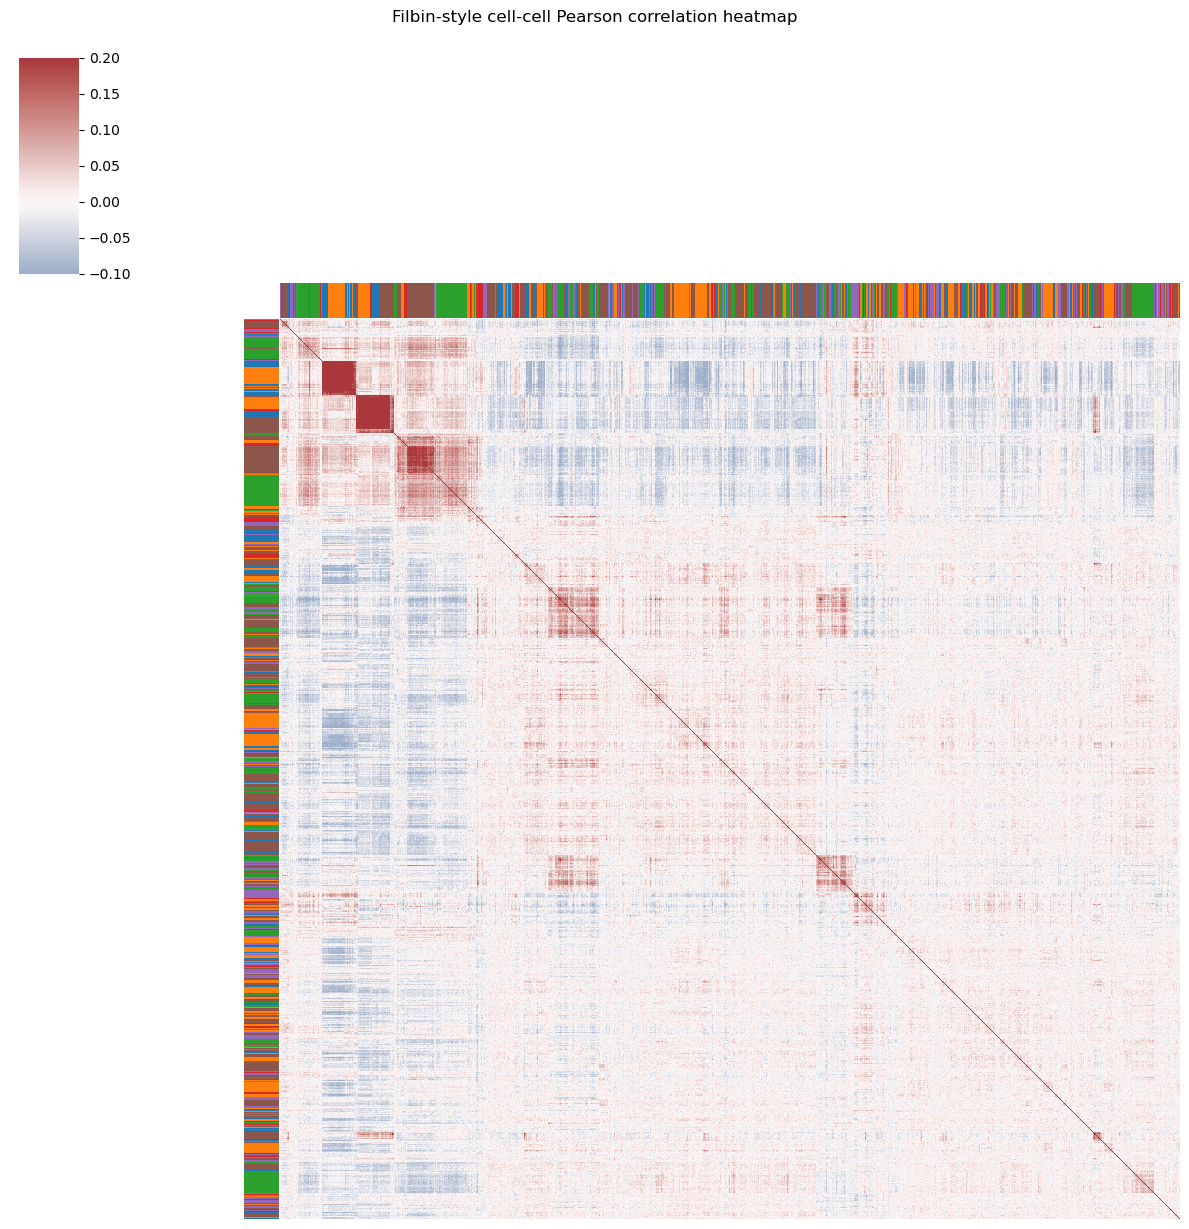

In [22]:
# Reordered numeric correlation matrix
corr_ordered_array = corr[np.ix_(order, order)]

# Reordered sample labels as a plain list
sample_ordered = adata.obs.iloc[order]["sample"].astype(str).to_list()

# Sample color mapping
unique_samples = sorted(set(sample_ordered))
palette = sns.color_palette("tab10", n_colors=len(unique_samples))
sample_lut = dict(zip(unique_samples, palette))

# Plain Python list of RGB tuples
sample_colors = [sample_lut[s] for s in sample_ordered]

g = sns.clustermap(
    corr_ordered_array,
    row_cluster=False,
    col_cluster=False,
    row_colors=sample_colors,
    col_colors=sample_colors,
    cmap="vlag",
    center=0,
    vmin=-0.1,
    vmax=0.2,
    xticklabels=False,
    yticklabels=False,
    figsize=(12, 12)
)

plt.suptitle("Filbin-style cell-cell Pearson correlation heatmap", y=1.02)
plt.show()

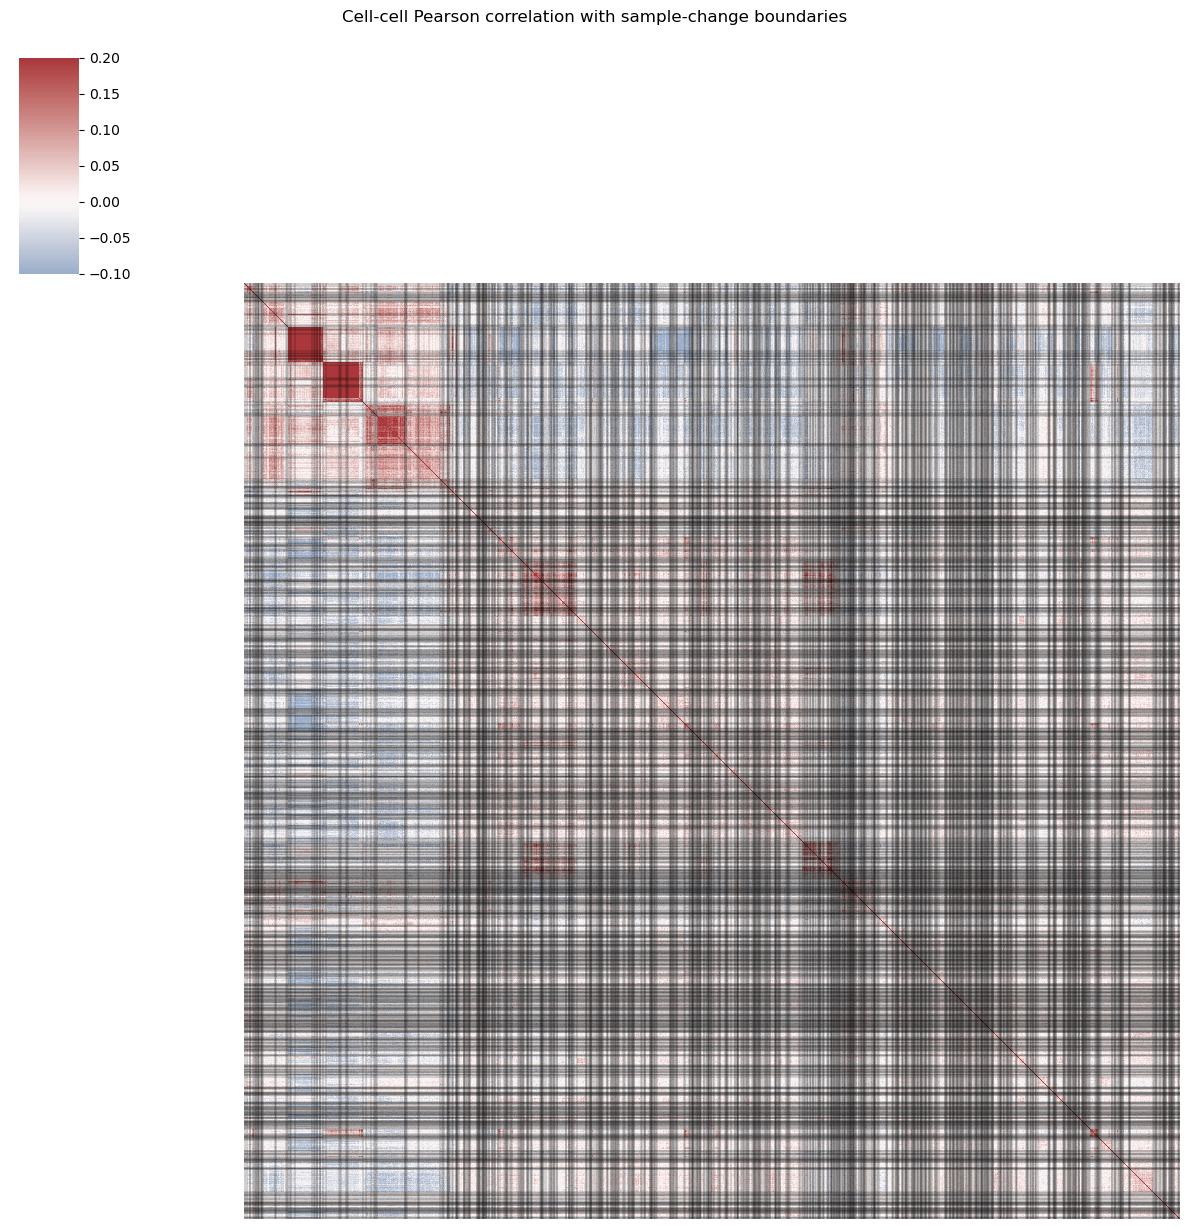

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

corr_ordered_array = corr[np.ix_(order, order)]
obs_ordered = adata.obs.iloc[order].copy()
obs_ordered["sample"] = obs_ordered["sample"].astype(str)

# Find positions where sample label changes along the clustered order
sample_changes = np.where(
    obs_ordered["sample"].values[1:] != obs_ordered["sample"].values[:-1]
)[0] + 1

g = sns.clustermap(
    corr_ordered_array,
    row_cluster=False,
    col_cluster=False,
    cmap="vlag",
    center=0,
    vmin=-0.1,
    vmax=0.2,
    xticklabels=False,
    yticklabels=False,
    figsize=(12, 12)
)

# Draw sample-boundary lines
for pos in sample_changes:
    g.ax_heatmap.axhline(pos, color="black", linewidth=0.2)
    g.ax_heatmap.axvline(pos, color="black", linewidth=0.2)

plt.suptitle("Cell-cell Pearson correlation with sample-change boundaries", y=1.02)
plt.show()

In [24]:
immune_markers = [
    "CD14", "CX3CR1", "AIF1", "PTPRC", "CD74", "CD68", "CSF1R", "TYROBP", "P2RY12"
]

oligo_markers = [
    "MBP", "PLP1", "MOG", "CLDN11", "MOBP", "MAG", "TF"
]

immune_markers_present = [g for g in immune_markers if g in adata.var_names]
oligo_markers_present = [g for g in oligo_markers if g in adata.var_names]

print("Immune markers present:", immune_markers_present)
print("Oligodendrocyte markers present:", oligo_markers_present)

Immune markers present: ['CD14', 'CX3CR1', 'AIF1', 'PTPRC', 'CD74', 'CD68', 'CSF1R', 'TYROBP', 'P2RY12']
Oligodendrocyte markers present: ['MBP', 'PLP1', 'MOG', 'CLDN11', 'MOBP', 'MAG', 'TF']


In [25]:
import scanpy as sc

sc.tl.score_genes(
    adata,
    gene_list=immune_markers_present,
    score_name="immune_score",
    use_raw=False
)

sc.tl.score_genes(
    adata,
    gene_list=oligo_markers_present,
    score_name="oligo_score",
    use_raw=False
)

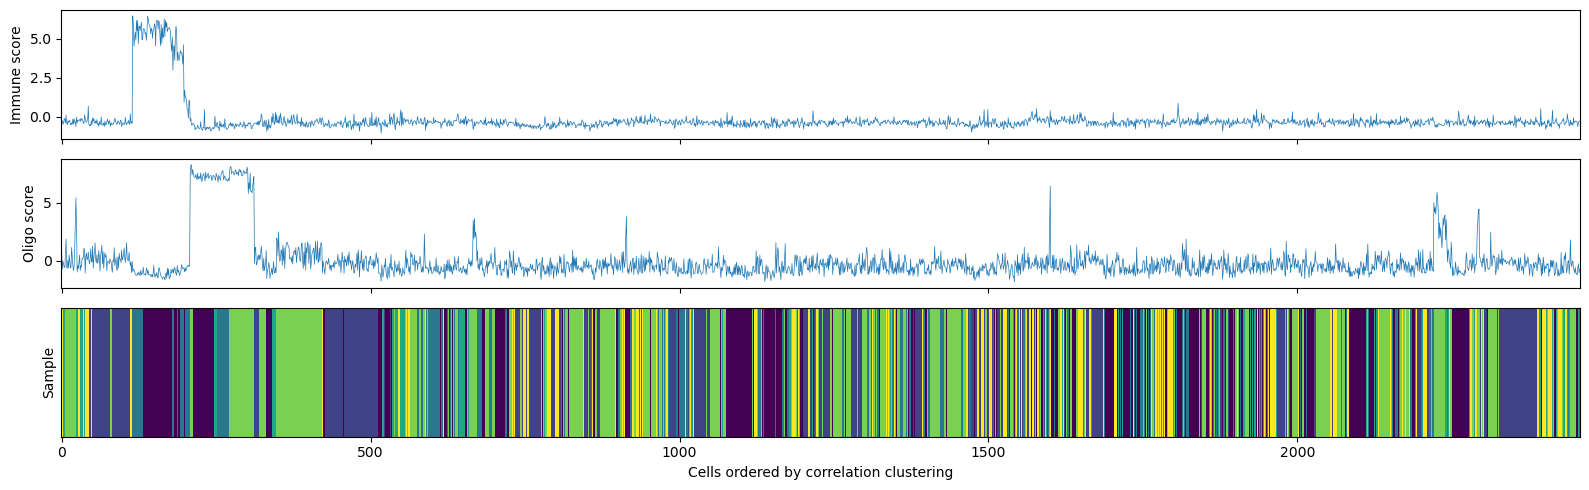

In [26]:
obs_ordered = adata.obs.iloc[order].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 5), sharex=True)

axes[0].plot(obs_ordered["immune_score"].values, linewidth=0.5)
axes[0].set_ylabel("Immune score")

axes[1].plot(obs_ordered["oligo_score"].values, linewidth=0.5)
axes[1].set_ylabel("Oligo score")

# Encode sample labels numerically only for visualization
sample_codes = pd.Categorical(obs_ordered["sample"]).codes
axes[2].imshow(sample_codes.reshape(1, -1), aspect="auto", interpolation="nearest")
axes[2].set_yticks([])
axes[2].set_ylabel("Sample")
axes[2].set_xlabel("Cells ordered by correlation clustering")

plt.tight_layout()
plt.show()